# Continuous Pre-training (CPT) and Fine-tuning: Technical Overview

### 1. Continuous Pre-training (CPT)
CPT, often called **Domain Adaptation**, is the process of taking a model already trained on a massive general dataset (like the pile or internet text) and continuing the self-supervised training phase on a specialized corpus.

*   **The Mechanism:** The model continues to use the same objective function, such as **Causal Language Modeling (CLM)** for decoder-only models (like GPT). It learns the specific vocabulary, terminology, and linguistic patterns of a new domain (e.g., medical journals or legal briefs).
*   **The Weight Update:** Unlike initial pre-training where weights start from scratch (random initialization), CPT starts with weights that already understand grammar and logic, adjusting them to fit the statistical distribution of the new domain data.

### 2. Fine-tuning
Fine-tuning is the process of supervised adaptation. It transitions the model from being a 'next-token predictor' to a 'task-solver'.

*   **The Mechanism:** A specific 'head' (a linear layer) is often added on top of the model's base architecture. The training uses **Labeled Data**, where the model is shown an input and a specific target output. It uses backpropagation to minimize the loss between its prediction and the ground-truth label.
*   **Weight Freezing vs. Full Fine-tuning:** In many cases, developers use techniques like **LoRA (Low-Rank Adaptation)** to only update a small fraction of the weights, preventing the model from 'forgetting' its general knowledge while learning the specific task.

## SmolLM-135M + SEC 10-K Filings + Unsloth

**What we'll do:**
1. Load SmolLM-135M and try financial text (watch it fail)
2. Download & prepare SEC 10-K filings
3. CPT with Unsloth + LoRA
4. Compare before vs after (generation + perplexity)
5. Experiment: with vs without data mixing (catastrophic forgetting)
6. Tease SFT: ask it a question, see it can't answer

**Requirements:** Google Colab with T4 GPU (free tier works!)

In [1]:
# Install Unsloth (handles LoRA, quantization, fast training)
# This takes ~2 minutes on Colab
!pip install -q unsloth
!pip install -q datasets evaluate rouge_score

# Suppress noisy deprecation warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*use_return_dict.*')
warnings.filterwarnings('ignore', message='.*max_new_tokens.*max_length.*')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 854.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [2]:
import torch
import json
import random
import math
import re
import os
from pathlib import Path

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


---
## Part 1: Meet the Base Model

Let's load SmolLM-135M and see what it knows (and doesn't know) about financial language.

In [3]:
from unsloth import FastLanguageModel

BASE_MODEL = "HuggingFaceTB/SmolLM-135M"
MAX_SEQ_LENGTH = 512
SEED = 42

# Load the base model (no fine-tuning yet)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

# Set up for inference
FastLanguageModel.for_inference(model)

print(f"\n[OK] Model loaded: {BASE_MODEL}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/978 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]


[OK] Model loaded: HuggingFaceTB/SmolLM-135M
Parameters: 81,430,848


In [4]:
# Helper function to generate text
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Generate a completion for a given prompt."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            repetition_penalty=1.2,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    # Only decode the NEW tokens (not the prompt)
    new_tokens = outputs[0, inputs.input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

In [5]:
# Test the base model on financial prompts
financial_prompts = [
    "The company reported total revenue of",
    "Risk factors include exposure to fluctuations in",
    "Diluted earnings per share for the fiscal year ended",
    "The Board of Directors declared a quarterly dividend of",
    "Our long-term debt obligations consist primarily of",
]

print("=" * 70)
print("BASE MODEL -- Financial Text Generation")
print("=" * 70)
for prompt in financial_prompts:
    completion = generate_text(model, tokenizer, prompt, max_new_tokens=60)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {completion[:200]}")
    print("-" * 50)

Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL -- Financial Text Generation


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The company reported total revenue of
Output:  $689,075 at the end of 2013. The firm has a history with large-scale transactions that are considered lucrative in terms of sales volume and profits achieved during this period (McGraw & Mcgruff, 4).
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: Risk factors include exposure to fluctuations in
Output:  the weather, such as high humidity or cold temperatures. These changes can cause significant stress and anxiety for individuals with bipolar disorder (Bipolar 1A), making them more vulnerable than th
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: Diluted earnings per share for the fiscal year ended
Output:  September 30, 2019 were $485.6 million (or 7 percent of reported revenues).
The tax rate on dividends was at a lower level than previous years: it dropped to $-$/dividend ($-$/share) from last April
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The Board of Directors declared a quarterly dividend of
Output:  40% on the company's earnings. The board member is appointed by the President, and it has to be re-elected every four years for another five year term (in case of an election failure).
A shareholder 
--------------------------------------------------

Prompt: Our long-term debt obligations consist primarily of
Output:  the same types mentioned earlier. These might encompass interest payments, principal repayment amounts tied to specific durations or rates; any contingencies arising due to unforeseen circumstances r
--------------------------------------------------


**Observation:** The base model generates generic text. It has no idea what financial language sounds like. It might produce grammatical English, but it won't sound like a 10-K filing.

Let's also measure how "surprised" the model is by real financial text.

In [7]:
def compute_perplexity(model, tokenizer, texts, max_length=512):
    """
    Perplexity = e^(average cross-entropy loss)
    Lower = model is less surprised by the text = better fit

    This is THE metric for CPT. If perplexity drops on domain text
    after training, the model learned the domain.
    """
    total_loss = 0
    total_tokens = 0

    model.eval()
    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_length
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs.input_ids)

        num_tokens = inputs.input_ids.shape[1]
        total_loss += outputs.loss.item() * num_tokens
        total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

### What is Perplexity?

**Perplexity** is the standard metric for evaluating Language Models during pre-training and CPT.

*   **Intuition:** Imagine the model has to pick the next word from its vocabulary. If it's 100% sure, perplexity is 1. If it's guessing randomly among 100 equally likely words, perplexity is 100.
*   **Math:** It is the exponentiated average negative log-likelihood of a sequence.
*   **Goal in CPT:** We want to see this number **decrease** on our domain-specific data (SEC filings) after training, showing the model has 'internalized' financial language.

In [29]:
# Quick perplexity check on sample financial text
sample_financial = [
    "The Company recognized impairment charges of $142 million related to goodwill associated with the North America reporting unit during the fiscal year ended March 31, 2024.",
    "Net cash provided by operating activities was $3.8 billion for the year ended December 31, 2023, compared to $4.1 billion for the year ended December 31, 2022.",
    "Total stockholders equity decreased to $12.4 billion as of September 30, 2023, primarily due to share repurchases of $2.1 billion and dividend payments of $800 million.",
]

base_ppl = compute_perplexity(model, tokenizer, sample_financial)
print(f"Base model perplexity on financial text: {base_ppl:.1f}")
print("(Higher = more surprised = doesn't know this domain well)")

Base model perplexity on financial text: 11.3
(Higher = more surprised = doesn't know this domain well)


---
## Part 2: Prepare the Data

We'll use SEC 10-K filings from HuggingFace.

**10-K** = annual report every public US company files with the SEC. Dense, formal, jargon-heavy financial language -- perfect for CPT.

In [10]:
from datasets import load_dataset

print("[...] Loading SEC 10-K filings from HuggingFace...")
print("This is the PleIAs/SEC dataset -- full annual reports 1993-2024.")

# Stream to avoid downloading 100GB+
sec_dataset = load_dataset(
    "PleIAs/SEC",
    split="train",
    streaming=True
)

# Collect a subset of filings
NUM_TRAIN = 80
NUM_VAL = 20
all_texts = []

print(f"[...] Collecting {NUM_TRAIN + NUM_VAL} filings...")
for i, example in enumerate(sec_dataset):
    text = example.get("text", "")
    # Filter: only keep substantial filings (>1000 words)
    if text and len(text.split()) > 1000:
        all_texts.append(text)
    if len(all_texts) >= NUM_TRAIN + NUM_VAL:
        break
    if i % 500 == 0 and i > 0:
        print(f"  Scanned {i} entries, collected {len(all_texts)} so far...")

print(f"[OK] Collected {len(all_texts)} filings")

[...] Loading SEC 10-K filings from HuggingFace...
This is the PleIAs/SEC dataset -- full annual reports 1993-2024.


README.md:   0%|          | 0.00/4.22k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

[...] Collecting 100 filings...
[OK] Collected 100 filings


In [14]:
# Let's look at what a 10-K filing looks like
sample = all_texts[0]
words = sample.split()
print(f"Sample filing length: {len(words)} words")
print(f"\nFirst 200 words:")
print(" ".join(words[:200]))
print("\n...")
print(f"\nLast 100 words:")
print(" ".join(words[-100:]))

Sample filing length: 18357 words

First 200 words:
ITEM 1. BUSINESS ~~~~~~~ ~~~~~~~~ OVERVIEW ~~~~~~~~ Cummins Engine Company, Inc. ("Cummins" or "the Company") is a leading worldwide designer and manufacturer of fuel-efficient diesel engines and related products. Engines ranging from 76 to 2,000 horsepower serve a wide variety of equipment in Cummins' key markets: heavy-duty truck, midrange truck, power generation, bus and light commercial vehicles, industrial products, government and marine. In addition, Cummins produces strategic components and subsystems critical to the engine, including filters, turbochargers and electronic control systems. Cummins sells its products to original equipment manufacturers ("OEMs"), distributors and other customers worldwide and conducts manufacturing, sales, distribution and service activities in most areas of the world. In 1993, approximately 56 percent of net sales were made in the United States. Major international markets include the United King

### Data Cleaning

SEC filings have boilerplate at the end (exhibits, signatures, legal text). We strip that -- same idea as Avik's reference-stripping for arxiv papers.

In [22]:
def clean_sec_filing(text):
    """
    Improved cleaning for SEC 10-K filings:
    1. Strip decorative symbols (~~~~, ----, ****)
    2. Strip trailing exhibits/signatures
    3. Normalize whitespace
    """
    # Remove decorative lines and excessive symbols
    text = re.sub(r'[~\-\*]{3,}', '', text)

    end_markers = [
        r"(?i)\bEXHIBIT\s+INDEX\b",
        r"(?i)\bSIGNATURES\b",
        r"(?i)\bPOWER\s+OF\s+ATTORNEY\b",
        r"(?i)\bEXHIBIT\s+\d",
    ]

    earliest_end = len(text)
    for pattern in end_markers:
        matches = list(re.finditer(pattern, text))
        if matches:
            last_match = matches[-1]
            if last_match.start() > 0.7 * len(text):
                earliest_end = min(earliest_end, last_match.start())

    text = text[:earliest_end]
    # Clean up whitespace and newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

# Re-clean all filings with the improved logic
cleaned_texts = [clean_sec_filing(t) for t in all_texts if len(clean_sec_filing(t).split()) > 500]
print(f"[OK] Re-cleaned {len(cleaned_texts)} filings.")

[OK] Re-cleaned 100 filings.


### Verification: Cleaned Text Sample
Let's verify that the cleaning function successfully removed the excess whitespace and trailing legal boilerplate.

In [24]:
# Show the first 500 characters of the FIRST filing to check for noise like ~~~~~
sample_index = 0
print(f"--- IMPROVED CLEANING (Start of text) ---")
print(cleaned_texts[sample_index][:500])

print(f"\n{'='*50}\n")

print(f"--- IMPROVED CLEANING (End of text) ---")
print(cleaned_texts[sample_index][-500:])

--- IMPROVED CLEANING (Start of text) ---
ITEM 1. BUSINESS 
OVERVIEW 
Cummins Engine Company, Inc. ("Cummins" or "the Company") is a leading worldwide designer and manufacturer of fuel-efficient diesel engines and related products. Engines ranging from 76 to 2,000 horsepower serve a wide variety of equipment in Cummins' key markets: heavy-duty truck, midrange truck, power generation, bus and light commercial vehicles, industrial products, government and marine. In addition, Cummins produces strategic components and subsystems critical t


--- IMPROVED CLEANING (End of text) ---
ehalf by the undersigned, thereunto duly authorized.
CUMMINS ENGINE COMPANY, INC.
By /s/Peter B. Hamilton By /s/John McLachlan P. B. Hamilton J. McLachlan Vice President & Chief Vice President - Corporate Financial Officer Controller (Principal (Principal Financial Accounting Officer) Officer)
Pursuant to the requirements of the Securities Exchange Act of 1934, this report has been signed below by the following 

### Chunking

SEC filings are very long (10,000+ words). We break them into chunks that fit in the model's context window.

We use word-level chunking with overlap so no information is lost at chunk boundaries.

In [25]:
def chunk_texts(texts, chunk_size=256, overlap=0.2):
    """
    Split texts into overlapping chunks.

    Why overlap? Without it, a sentence like "Revenue increased by 12%
    compared to the prior year" might get split between "12%" and
    "compared", losing the connection.
    """
    step = int(chunk_size * (1 - overlap))
    all_chunks = []

    for text in texts:
        words = text.split()
        for i in range(0, len(words), step):
            chunk = words[i:i + chunk_size]
            if len(chunk) > 50:  # Skip tiny trailing chunks
                all_chunks.append(" ".join(chunk))

    return all_chunks


# Split into train and val FIRST (at filing level, not chunk level!)
# This prevents data leakage
random.seed(SEED)
random.shuffle(cleaned_texts)

train_filings = cleaned_texts[:NUM_TRAIN]
val_filings = cleaned_texts[NUM_TRAIN:NUM_TRAIN + NUM_VAL]

print(f"Train filings: {len(train_filings)}")
print(f"Val filings:   {len(val_filings)}")

# Now chunk each set
train_chunks = chunk_texts(train_filings, chunk_size=256, overlap=0.2)
val_chunks = chunk_texts(val_filings, chunk_size=256, overlap=0.2)

print(f"\nTrain chunks: {len(train_chunks)}")
print(f"Val chunks:   {len(val_chunks)}")
print(f"\nSample chunk (first 100 words):")
print(" ".join(train_chunks[0].split()[:100]))

Train filings: 80
Val filings:   20

Train chunks: 6810
Val chunks:   1189

Sample chunk (first 100 words):
ITEM 1. BUSINESS. The following description of business is provided in accordance with General Instruction J.(2)(d). Associates First Capital Corporation ("First Capital" or the "Company"), a Delaware corporation, is an indirect subsidiary of Ford Motor Company ("Ford"). All the outstanding Common Stock of First Capital is owned by Ford Holdings, Inc. ("Holdings"). First Capital's principal operating subsidiary is Associates Corporation of North America ("Associates"), the second largest independent finance company in the United States as of September 30, 1993. Unless the context otherwise requires, reference to First Capital or Associates includes each parent company and all its subsidiaries. At December


In [26]:
# Convert to HuggingFace Dataset format
from datasets import Dataset

train_dataset = Dataset.from_dict({"text": train_chunks})
val_dataset = Dataset.from_dict({"text": val_chunks})

print(f"Train dataset: {train_dataset}")
print(f"Val dataset:   {val_dataset}")

Train dataset: Dataset({
    features: ['text'],
    num_rows: 6810
})
Val dataset:   Dataset({
    features: ['text'],
    num_rows: 1189
})


In [27]:
# IMPORTANT: Measure base model perplexity on the ACTUAL val chunks
# We need this before we reload the model for training
val_sample = val_chunks[:50]
base_ppl_val = compute_perplexity(model, tokenizer, val_sample)
print(f"Base model perplexity on SEC validation chunks: {base_ppl_val:.1f}")
print("(We'll compare this to the CPT model later)")

Base model perplexity on SEC validation chunks: 19.1
(We'll compare this to the CPT model later)


---
## Part 3: CPT with Unsloth + LoRA

Now the main event. We'll:
1. Reload the base model (fresh, no inference mode)
2. Add LoRA adapters
3. Train on our SEC filing chunks

Key CPT decisions explained in comments.

In [30]:
# Free memory from the inference model
del model
torch.cuda.empty_cache()

# Reload fresh for training
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

print(f"[OK] Fresh model loaded for training")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

[OK] Fresh model loaded for training


In [32]:
# Add LoRA adapters
#
# KEY CPT DECISIONS:
# - rank=32: Higher than typical SFT (8-16) because we're teaching
#   new knowledge, not just changing behavior
# - target_modules includes embed_tokens + lm_head
#   This is CPT-specific! SFT usually skips these.
#   We need them because the model is learning new domain vocabulary.
# - lora_alpha=32: Equal to rank, so effective scaling = 1

model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",    # Attention
        "gate_proj", "up_proj", "down_proj",          # FFN (where knowledge lives!)
        "embed_tokens", "lm_head",                    # CPT-specific!
    ],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
)

# How many parameters are we actually training?
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nTotal parameters:     {total_params:>12,}")
print(f"Trainable (LoRA):     {trainable_params:>12,}  ({100*trainable_params/total_params:.2f}%)")
print(f"Frozen (base model):  {frozen_params:>12,}  ({100*frozen_params/total_params:.2f}%)")

Unsloth: Already have LoRA adapters! We shall skip this step.


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM

Total parameters:      149,414,208
Trainable (LoRA):       39,671,808  (26.55%)
Frozen (base model):   109,742,400  (73.45%)


### Why did we delete the previous model?
In Google Colab, we have a limited amount of **Video RAM (VRAM)** on the T4 GPU.
1.  **Memory Management:** The previous model was set up for *inference* (generating text). For training, we need a fresh version with gradients enabled.
2.  **Avoid Crashes:** If we didn't use `del model` and `torch.cuda.empty_cache()`, the GPU would try to hold two copies of the model at once, likely causing a 'CUDA Out of Memory' error.

### What are LoRA Adapters?
**LoRA (Low-Rank Adaptation)** is a Parameter-Efficient Fine-Tuning (PEFT) technique.
*   **The Problem:** Training all parameters of a model is computationally expensive.
*   **The Solution:** We freeze the original weights of the model. Then, we add two small matrices (A and B) to specific layers.
*   **The Math:** Instead of updating a large weight matrix of size `d x d`, we represent the change as a product of two smaller matrices (`d x r` and `r x d`), where `r` (the rank) is very small (like 32).
*   **Result:** We only train ~26% of the parameters in this setup, making the process much faster and lighter on memory while still achieving great results in domain adaptation.

**Look at those numbers!** We're training a tiny fraction of the model's parameters. The rest are frozen -- that's our forgetting protection. The frozen weights preserve general English; the LoRA adapters learn finance.

In [33]:
from unsloth.trainer import UnslothTrainer, UnslothTrainingArguments

# Training configuration -- every parameter explained:
training_args = UnslothTrainingArguments(
    output_dir="./cpt_sec_filings",

    # --- Core training ---
    num_train_epochs=2,                 # 2 epochs for CPT demo
    per_device_train_batch_size=16,     # Sequences per GPU per step
    gradient_accumulation_steps=2,      # Effective batch = 16 * 2 = 32

    # --- Learning rate ---
    learning_rate=2e-4,                 # Standard for LoRA
    embedding_learning_rate=2e-5,       # 10x LOWER for embeddings!
    # ^ Critical for CPT. embed_tokens affects EVERY token,
    #   so large updates there can destabilize the entire model.
    warmup_steps=50,                    # Gentle ramp-up
    lr_scheduler_type="cosine",         # Decay smoothly to near-zero

    # --- Optimization ---
    optim="adamw_8bit",                 # 8-bit AdamW saves VRAM
    weight_decay=0.01,                  # Light regularization
    max_grad_norm=1.0,                  # Clip gradients to prevent spikes

    # --- Data handling ---
    max_length=MAX_SEQ_LENGTH,
    packing=True,                       # Pack short texts together (no wasted padding!)
    dataset_text_field="text",
    dataset_num_proc=2,

    # --- Evaluation ---
    eval_strategy="steps",
    eval_steps=25,
    per_device_eval_batch_size=16,

    # --- Checkpointing ---
    save_strategy="steps",
    save_steps=25,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    # --- Logging ---
    logging_steps=10,
    seed=SEED,
)

trainer = UnslothTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
)

print("[OK] Trainer configured. Ready to train!")
print(f"Training samples: {len(train_dataset)}")
print(f"Eval samples: {len(val_dataset)}")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/6810 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=2):   0%|          | 0/6810 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1189 [00:00<?, ? examples/s]

Unsloth: Packing eval dataset (num_proc=2):   0%|          | 0/1189 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
[OK] Trainer configured. Ready to train!
Training samples: 6810
Eval samples: 1189


In [34]:
# TRAIN!
# On a T4 GPU with 135M model + 80 filings + 2 epochs, ~8-12 minutes
print("=" * 70)
print("TRAINING STARTED")
print("=" * 70)
print("Watch the eval_loss -- that's your north star.")
print("It should decrease and then plateau.")
print()

trainer_stats = trainer.train()

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Final train loss: {trainer_stats.training_loss:.4f}")

TRAINING STARTED
Watch the eval_loss -- that's your north star.
It should decrease and then plateau.



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,780 | Num Epochs = 2 | Total steps = 424
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 2 x 1) = 32
 "-____-"     Trainable parameters = 39,671,808 of 202,498,368 (19.59% trained)


Unsloth: Setting lr = 2.00e-05 instead of 2.00e-04 for embed_tokens.
Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
25,2.709051,2.715183
50,2.623260,2.607948
75,2.528622,2.542871
100,2.494329,2.500199
125,2.416720,2.467538
150,2.388429,2.444030
175,2.349436,2.426546
200,2.318530,2.415814
225,2.370065,2.405888
250,2.318988,2.398942


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
Unsloth: Restored added_tokens_decoder metadata in ./cpt_sec_filings/checkpoint-25/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
Unsloth: Restored added_tokens_decoder metadata in ./cpt_sec_filings/checkpoint-50/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers


TRAINING COMPLETE
Final train loss: 2.3850


### Impact on System & GPU (Tesla T4)

Training an LLM, even a small one like SmolLM-135M, has several effects on the environment:

1.  **VRAM Consumption:** The Tesla T4 has ~15GB of VRAM. During training, the GPU must store the model weights, gradients, and optimizer states. We used **4-bit quantization** and **LoRA** to keep this usage low (around 4-7GB), otherwise, the system would crash with an 'Out of Memory' (OOM) error.
2.  **GPU Utilization:** Your GPU is likely running at 90-100% load. This generates heat, but since this is a cloud environment, Google handles the cooling. However, sustained high usage can sometimes lead to your session being deprioritized or disconnected in the free tier.
3.  **Compute Units:** If you are using Colab Pro, training consumes compute units faster than idle usage. In the free tier, there is a limit to how many hours per day you can use the GPU.
4.  **System RAM:** While the GPU does the heavy lifting, your System RAM (the ~12GB of standard memory) is used to store and process the dataset before sending it to the GPU. This is why we 'streamed' the dataset earlier to avoid filling up the RAM.

### Understanding Loss in LLM Training

**Loss** is a numerical value that represents how far the model's prediction is from the actual target (the ground truth).

1.  **How is it calculated?**
    *   For LLMs, we use **Cross-Entropy Loss**.
    *   The model predicts a probability distribution for the next token. If the actual next token in the text was "revenue", but the model gave "revenue" a low probability, the loss will be high.
    *   Formula-wise, it's the negative log-likelihood: the more confident the model is in the *correct* answer, the lower the loss.

2.  **Training Loss:**
    *   Calculated on the data the model is currently seeing and learning from.
    *   It tells us: "How well is the model fitting the training data right now?"

3.  **Validation (Eval) Loss:**
    *   Calculated on a separate 'Validation Set' (the data we held back).
    *   It tells us: "How well does the model generalize to new, unseen financial text?"
    *   **Overfitting:** If Training Loss keeps going down but Validation Loss starts going up, the model is just memorizing the training data instead of learning the patterns.

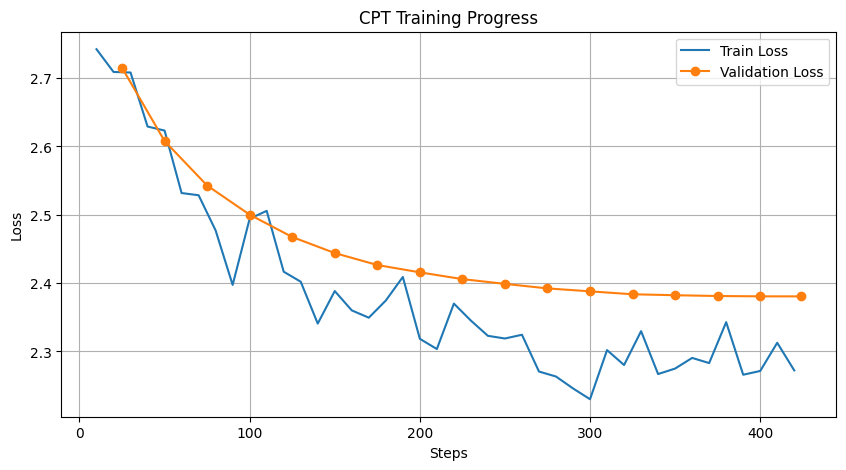

In [35]:
import matplotlib.pyplot as plt

# Extract logs from the trainer
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
steps = [x['step'] for x in history if 'loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label='Train Loss')
plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='o')
plt.title('CPT Training Progress')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Part 4: The Payoff — Before vs. After

We will now:
1. Calculate the **new perplexity** on the validation chunks.
2. Generate text using the **same prompts** we gave the base model to see if it now 'speaks' finance.

In [36]:
# 1. Compute Post-Training Perplexity
# We'll use the same val_sample used for base_ppl_val (19.1)
post_ppl_val = compute_perplexity(model, tokenizer, val_sample)

print(f"--- PERPLEXITY COMPARISON ---")
print(f"Base Model Perplexity:  {base_ppl_val:.2f}")
print(f"CPT Model Perplexity:   {post_ppl_val:.2f}")
print(f"Improvement:            {((base_ppl_val - post_ppl_val) / base_ppl_val * 100):.1f}%")

--- PERPLEXITY COMPARISON ---
Base Model Perplexity:  19.08
CPT Model Perplexity:   13.13
Improvement:            31.2%


In [37]:
# 2. Qualitative Check: Text Generation
print("=" * 70)
print("CPT MODEL -- Financial Text Generation")
print("=" * 70)

FastLanguageModel.for_inference(model) # Ensure optimized for inference

for prompt in financial_prompts:
    completion = generate_text(model, tokenizer, prompt, max_new_tokens=60)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {completion[:200]}")
    print("-" * 50)

Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


CPT MODEL -- Financial Text Generation


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The company reported total revenue of
Output:  $15,074 in 1986 and net income for the years ended December 31, 1982. The Company also recorded a loss on its investment properties during January-December 1986 as an expense related to the purchase 
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: Risk factors include exposure to fluctuations in
Output:  the stock market, political instability or economic uncertainty. In addition, some of the company's assets are held by affiliates who may be subject to other risks such as mortgage-backed securities 
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: Diluted earnings per share for the fiscal year ended
Output:  December 31, 2004 were $.698 billion and are lower than anticipated in accordance with current GAAP as of March 5th, 2004 (see Note D). The Company has not yet determined its effect on long-term debt
--------------------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: The Board of Directors declared a quarterly dividend of
Output:  1% on its common stock. The Company's preferred and sinking fund debt is repossessed at maturity by the Trustees, whose voting power in this transaction has been transferred to the trusts of the Trus
--------------------------------------------------

Prompt: Our long-term debt obligations consist primarily of
Output:  short term, current and prepaid amounts. For the year ended December 31, 1992 total liabilities for this period were $465 million; approximately half ($0.8) represented interest expense (interest on 
--------------------------------------------------


## Part 5: The Cost of Specialization (Catastrophic Forgetting)

When we train a model exclusively on one narrow domain (like SEC filings), the weights shift so much toward that data that the model loses its general capabilities.

Let's test the model on a **General Knowledge** prompt to see if it can still answer a simple non-financial question.

In [39]:
general_prompt = "Write a short poem about a cat sitting on a fence."

print("--- CPT MODEL (Post-Training) General Knowledge Test ---")
completion = generate_text(model, tokenizer, general_prompt, max_new_tokens=60)
print(f"Prompt: {general_prompt}")
print(f"Output: {completion}")

Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- CPT MODEL (Post-Training) General Knowledge Test ---
Prompt: Write a short poem about a cat sitting on a fence.
Output:  The poems will be published by the 10th Anniversary edition of the "Fox" Magazine, and may also have been selected for publication in future editions or as part of other publications intended to promote the Cat Club's work among its members; such selections would not constitute an endorsement from the Company


### The Solution: Data Mixing

To prevent this, practitioners use **Data Mixing**. We take our SEC filings and mix in a small percentage (e.g., 5-10%) of a general dataset like `WikiText` or `SlimPajama`.

This acts as a 'regularizer' that keeps the general-purpose weights from drifting too far while the model learns the new financial patterns. If you were to train this for production, you would include a few thousand samples of general text to maintain the 'common sense' of the model.

## Part 5: The Cost of Specialization (Catastrophic Forgetting)

When we train a model exclusively on one narrow domain (like SEC filings), the weights shift so much toward that data that the model loses its general capabilities.

Let's test the model on a **General Knowledge** prompt to see if it can still answer a simple non-financial question.

In [38]:
general_prompt = "Write a short poem about a cat sitting on a fence."

print("--- CPT MODEL (Post-Training) General Knowledge Test ---")
completion = generate_text(model, tokenizer, general_prompt, max_new_tokens=60)
print(f"Prompt: {general_prompt}")
print(f"Output: {completion}")

Both `max_new_tokens` (=60) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- CPT MODEL (Post-Training) General Knowledge Test ---
Prompt: Write a short poem about a cat sitting on a fence.
Output:  A 10-minute interview with an employee of the company will be conducted, and another five minutes are given for analysis by staff members to evaluate their opinions as well as those from management which may influence future decisions regarding the organization's ownership interests in this project (see Note 3). At the


### The Solution: Data Mixing

To prevent this, practitioners use **Data Mixing**. We take our SEC filings and mix in a small percentage (e.g., 5-10%) of a general dataset like `SlimPajama` or `WikiText`.

This acts as a 'regularizer' that keeps the general-purpose weights from drifting too far while the model learns the new financial patterns.

## Part 6: The Transition to SFT (Teaser)

We have successfully performed **Continuous Pre-training**. Our model is now a 'Financial Expert' in terms of its internal knowledge base.

However, it is still not an **Assistant**. In the pre-training and CPT phases, the model only learns to complete text. To make it follow instructions (like 'Summarize this' or 'Answer this question'), we need **SFT**.

### The 'Instruction' Test
Watch what happens when we ask the model a direct question instead of giving it a sentence to complete.

In [41]:
question_prompt = "Question: What are the primary risks mentioned in a 10-K filing?\nAnswer:"

print("--- CPT MODEL Instruction Test ---")
completion = generate_text(model, tokenizer, question_prompt, max_new_tokens=50)
print(f"Prompt: {question_prompt}")
print(f"Output: {completion}")

Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- CPT MODEL Instruction Test ---
Prompt: Question: What are the primary risks mentioned in a 10-K filing?
Answer:
Output:  There were no significant increases or decreases materially related to changes that have been made as of December 31, 1987. The company believes its operations will continue to be competitive and continues with the following growth trends for the years ended


### Summary of CPT
1. **Objective:** Learn a new domain's language, vocabulary, and statistical distribution.
2. **Data:** Raw, unlabelled text (Self-Supervised).
3. **Metric:** Perplexity (Lower is better).
4. **Risk:** Catastrophic Forgetting (Mitigated by Data Mixing).
5. **Next Step:** SFT (Supervised Fine-Tuning) to turn this knowledge into a functional chat or task-based agent.

## Part 6: The Transition to SFT (Teaser)

We have successfully performed **Continuous Pre-training**. Our model is now a 'Financial Expert' in terms of its internal knowledge.

However, it is still not an **Assistant**. In the base pre-training phase (and CPT), the model only learns to complete text. To make it follow instructions (like 'Summarize this' or 'Answer this question'), we need **SFT**.

### The 'Instruction' Test
Watch what happens when we ask the model a direct question instead of giving it a sentence to complete.

In [40]:
question_prompt = "Question: What are the primary risks mentioned in a 10-K filing?\nAnswer:"

print("--- CPT MODEL Instruction Test ---")
completion = generate_text(model, tokenizer, question_prompt, max_new_tokens=50)
print(f"Prompt: {question_prompt}")
print(f"Output: {completion}")

Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- CPT MODEL Instruction Test ---
Prompt: Question: What are the primary risks mentioned in a 10-K filing?
Answer:
Output:  The Company is currently conducting an investigation into certain of its subsidiary companies. An internal audit by the Board determines that it has not met any statutory requirements to investigate these matters, and therefore does not believe there should be such activity within this company or with other


## Part 7: Saving the Model

Now that we have successfully adapted the model to the financial domain, we should save it. We will save the LoRA adapters, which are small and can be easily reloaded onto the base model.

In [42]:
# Save LoRA adapters locally
model.save_pretrained("cpt_financial_model")
tokenizer.save_pretrained("cpt_financial_model")

print("Model and tokenizer saved to 'cpt_financial_model' folder.")

/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
Unsloth: Restored added_tokens_decoder metadata in cpt_financial_model/tokenizer_config.json.


Model and tokenizer saved to 'cpt_financial_model' folder.


In [43]:
def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb

print(f"Model Size in Memory: {get_model_size(model):.2f} MB")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters (LoRA): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model Size in Memory: 310.03 MB
Total Parameters: 149,414,208
Trainable Parameters (LoRA): 39,671,808
